# Project Title

## E-Commerce Customer Behavior Analytics using Python, SQL Server & Power BI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving ecommerce_data.csv to ecommerce_data.csv


In [ ]:
df=pd.read_csv(r'/content/ecommerce_data.csv')
df

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,top_category_bought,avg_rating_given,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,Beauty,3.00,5,desktop,email,2022-03-18T01:58:29,2025-06-25T14:09:53,0,low,1
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,Sports,NaN,3,mobile,organic,2021-06-09T11:10:13,2025-01-02T01:01:29,0,low,1
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,Electronics,NaN,5,mobile,direct,2020-07-04T06:53:11,2025-08-28T11:01:14,0,low,0
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,Beauty,NaN,9,desktop,direct,2020-09-29T02:46:16,2024-11-27T23:38:49,0,medium,1
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,Beauty,3.67,9,desktop,organic,2020-01-31T02:47:48,2025-01-29T23:45:28,0,medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,Leroy Proctor,hannah36@example.net,GB,28,25-34,2025-04-28,True,1,65.53,...,Sports,NaN,2,mobile,paid,2021-04-04T08:08:51,2022-04-02T17:51:19,0,low,0
19996,19997,Stephanie Murphy MD,kristina47@example.org,US,64,55+,2022-06-22,False,0,0.00,...,NaN,NaN,4,desktop,social,2021-04-05T11:28:26,2024-02-05T18:58:58,1,no_purchase,0
19997,19998,David Lara,erik91@example.com,BR,23,18-24,2020-08-30,True,4,568.55,...,Toys,5.00,9,desktop,direct,2020-12-09T07:19:37,2025-03-04T05:34:33,0,medium,1
19998,19999,Erik Mitchell,warrenvictoria@example.org,CA,25,25-34,2024-09-16,False,2,57.36,...,Books,5.00,7,mobile,direct,2021-10-26T14:30:30,2025-10-24T01:40:32,0,low,1


In [ ]:
df.shape

(20000, 27)

In [ ]:
df1=df.copy()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            20000 non-null  int64  
 1   name                   20000 non-null  object 
 2   email                  20000 non-null  object 
 3   country                20000 non-null  object 
 4   age                    20000 non-null  int64  
 5   age_group              20000 non-null  object 
 6   signup_date            20000 non-null  object 
 7   marketing_opt_in       20000 non-null  bool   
 8   total_orders           20000 non-null  int64  
 9   total_spend_usd        20000 non-null  float64
 10  avg_order_value        20000 non-null  float64
 11  avg_discount_pct       20000 non-null  float64
 12  first_order_date       16268 non-null  object 
 13  last_order_date        16268 non-null  object 
 14  preferred_payment      16268 non-null  object 
 15  pr

In [ ]:
df1.describe()

,customer_id,age,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,avg_rating_given,total_sessions,has_abandoned_cart,is_repeat_customer
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,5259.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,46.492550,1.679000,224.660873,109.137204,5.815729,3.930276,6.000000,0.183850,0.502250
std,5773.647028,16.767961,1.292959,262.272901,122.423757,6.025030,0.889449,2.468219,0.387372,0.500007
min,1.000000,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5000.750000,32.000000,1.000000,32.160000,27.140000,0.000000,3.500000,4.000000,0.000000,0.000000
50%,10000.500000,46.500000,2.000000,145.390000,82.580000,5.000000,4.000000,6.000000,0.000000,1.000000
75%,15000.250000,61.000000,2.000000,322.400000,151.052500,10.000000,4.500000,8.000000,0.000000,1.000000
max,20000.000000,75.000000,9.000000,3026.420000,2680.640000,20.000000,5.000000,17.000000,1.000000,1.000000


In [ ]:
df1.isnull().sum()

,0
customer_id,0
name,0
email,0
country,0
age,0
age_group,0
signup_date,0
marketing_opt_in,0
total_orders,0
total_spend_usd,0


The dataset contains missing values across multiple columns. Upon investigation, it was observed that the date-related columns (first_order_date, last_order_date, first_session_date, and last_session_date) contain null values because some customers have never placed an order or never had a recorded session. Since these missing values carry meaningful business information, they were retained instead of being imputed with mean, median, or any arbitrary date values.

For the remaining categorical and numerical columns, missing values were handled based on their business context. Categorical columns related to purchasing behavior were filled with appropriate labels such as 'No Purchase', while avg_rating_given was imputed with 0 to represent customers who had not provided any ratings. This approach preserves all customer records and maintains the integrity of the business information.

In [ ]:
df1['preferred_payment'].value_counts()

,count
preferred_payment,
card,13522
paypal,1451
wallet,799
cod,496


In [ ]:
df1['preferred_payment']=df1['preferred_payment'].fillna('no purchase history')

In [ ]:
df1['preferred_payment']=df1['preferred_payment'].str.title()

In [ ]:
df1['preferred_device_ord'].value_counts()

,count
preferred_device_ord,
mobile,8050
desktop,7720
tablet,498


In [ ]:
df1['preferred_device_ord']=df1['preferred_device_ord'].fillna('no orders history')

In [ ]:
df1['preferred_device_ord']=df1['preferred_device_ord'].str.title()

In [ ]:
df1['preferred_source'].value_counts()

,count
preferred_source,
direct,6013
organic,5465
email,1666
paid,1335
social,1038
referral,751


In [ ]:
df1['preferred_source']=df1['preferred_source'].fillna('no source')

In [ ]:
df1['preferred_source']=df1['preferred_source'].str.title()

In [ ]:
df1['top_category_bought'].value_counts()

,count
top_category_bought,
Beauty,4306
Books,3459
Fashion,2290
Home & Kitchen,1834
Toys,1673
Sports,1392
Electronics,1314


In [ ]:
df1['top_category_bought']=df1['top_category_bought'].fillna('No Purchase')

In [ ]:
df1['top_category_bought']=df1['top_category_bought'].str.title()

In [ ]:
df1['avg_rating_given'].value_counts()

,count
avg_rating_given,
4.00,1387
5.00,1118
3.00,666
4.50,447
3.50,313
...,...
3.22,1
4.22,1
4.44,1


In [ ]:
df1['avg_rating_given']=df1['avg_rating_given'].fillna(0)

In [ ]:
df1['preferred_device_sess'].value_counts()

,count
preferred_device_sess,
mobile,11665
desktop,8142
tablet,138


The missing values in avg_rating_given are imputefd with 0,where 0 represents customers who havenot submitted any ratings.This tells us that no customer has lost there records during analysis

In [ ]:
df1['preferred_device_sess']=df1['preferred_device_sess'].fillna('No Session')

In [ ]:
df1['preferred_device_sess']=df1['preferred_device_sess'].str.title()

In [ ]:
df1['preferred_source_sess'].value_counts()

,count
preferred_source_sess,
organic,8598
direct,7893
email,1232
paid,992
social,831
referral,399


In [ ]:
df1['preferred_source_sess']=df1['preferred_source_sess'].fillna('No Session')

In [ ]:
df1['preferred_source_sess']=df1['preferred_source_sess'].str.title()

In [ ]:
df1.isnull().sum()

,0
customer_id,0
name,0
email,0
country,0
age,0
age_group,0
signup_date,0
marketing_opt_in,0
total_orders,0
total_spend_usd,0


In [ ]:
df1.duplicated().sum()

np.int64(0)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            20000 non-null  int64  
 1   name                   20000 non-null  object 
 2   email                  20000 non-null  object 
 3   country                20000 non-null  object 
 4   age                    20000 non-null  int64  
 5   age_group              20000 non-null  object 
 6   signup_date            20000 non-null  object 
 7   marketing_opt_in       20000 non-null  bool   
 8   total_orders           20000 non-null  int64  
 9   total_spend_usd        20000 non-null  float64
 10  avg_order_value        20000 non-null  float64
 11  avg_discount_pct       20000 non-null  float64
 12  first_order_date       16268 non-null  object 
 13  last_order_date        16268 non-null  object 
 14  preferred_payment      20000 non-null  object 
 15  pr

In [ ]:
df1['first_order_date']=pd.to_datetime(df1['first_order_date'],errors='coerce')
df1['last_order_date']=pd.to_datetime(df1['last_order_date'],errors='coerce')
df1['first_session_date']=pd.to_datetime(df1['first_session_date'],errors='coerce')
df1['last_session_date']=pd.to_datetime(df1['last_session_date'],errors='coerce')

In [ ]:
df1['signup_date']=pd.to_datetime(df1['signup_date'],errors='coerce')

In [ ]:
df1.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,top_category_bought,avg_rating_given,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,Beauty,3.00,5,Desktop,Email,2022-03-18 01:58:29,2025-06-25 14:09:53,0,low,1
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,Sports,0.00,3,Mobile,Organic,2021-06-09 11:10:13,2025-01-02 01:01:29,0,low,1
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,Electronics,0.00,5,Mobile,Direct,2020-07-04 06:53:11,2025-08-28 11:01:14,0,low,0
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,Beauty,0.00,9,Desktop,Direct,2020-09-29 02:46:16,2024-11-27 23:38:49,0,medium,1
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,Beauty,3.67,9,Desktop,Organic,2020-01-31 02:47:48,2025-01-29 23:45:28,0,medium,1


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_cols = num_cols.drop('customer_id')



In [ ]:
num_cols = num_cols.drop('has_abandoned_cart')
num_cols = num_cols.drop('is_repeat_customer')


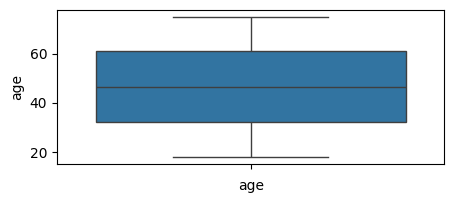

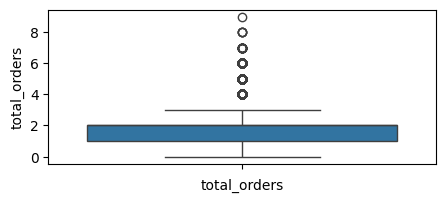

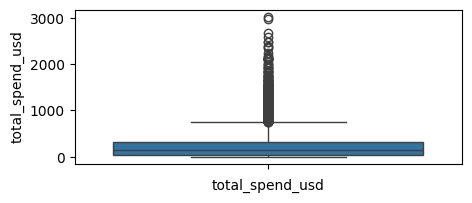

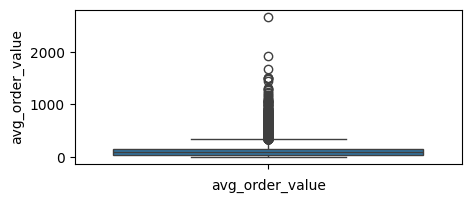

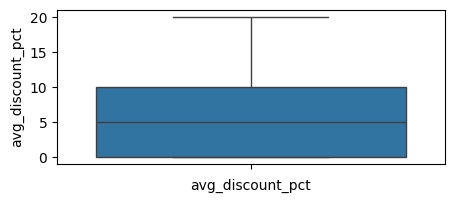

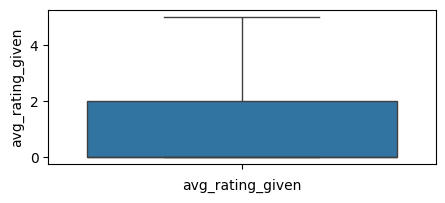

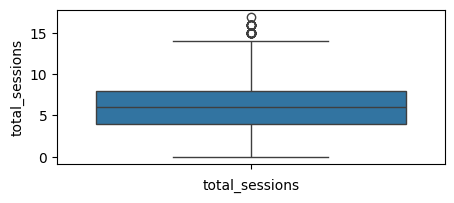

In [ ]:
for col in num_cols:
  plt.figure(figsize=(5,2))
  sns.boxplot(df1[col])
  plt.xlabel(col)
  plt.show()

Outlier analysis was performed using boxplots for numerical variables. Outliers observed in spending, order value, total orders, and session counts were retained because they represent genuine customer behavior and are important for customer segmentation and lifetime value analysis. Binary variables and identifier columns were excluded from outlier treatment.

**Performing Feature Engineering**

In [ ]:
df1['Customer_tenure']=(df1['last_order_date']-df1['first_order_date']).dt.days


In [ ]:
df1['tenure_category'] = pd.cut(
    df1['Customer_tenure'],
    bins=[-1,30,180,365,float('inf')],
    labels=[
        'New Customer',
        'Regular Customer',
        'Loyal Customer',
        'VIP Customer'
    ]
)

Customer Tenure measures the length of a customer's relationship with the company. It is calculated as the difference between the customer's last order date and first order date. This metric helps identify how long customers stay engaged with the business and can be used to classify customers into new, regular, loyal, and long-term customers.

In [ ]:
refernce_date=df1['last_order_date'].max()
df1['recency']=(refernce_date-df1['last_order_date']).dt.days

In [ ]:
df1['Frequency'] = df1['total_orders']

In [ ]:
df1['Monetary'] = df1['total_spend_usd']

RFM Analysis is a customer segmentation technique used to identify valuable customers based on their purchasing behavior. It evaluates customers using three metrics: Recency, Frequency, and Monetary value.

In [ ]:
df1.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,Customer_tenure,tenure_category,recency,Frequency,Monetary
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,2022-03-18 01:58:29,2025-06-25 14:09:53,0,low,1,1195.0,VIP Customer,128.0,2,115.39
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,2021-06-09 11:10:13,2025-01-02 01:01:29,0,low,1,382.0,VIP Customer,302.0,2,68.52
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,2020-07-04 06:53:11,2025-08-28 11:01:14,0,low,0,0.0,New Customer,1945.0,1,66.72
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,2020-09-29 02:46:16,2024-11-27 23:38:49,0,medium,1,1035.0,VIP Customer,822.0,2,279.86
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,2020-01-31 02:47:48,2025-01-29 23:45:28,0,medium,1,228.0,Loyal Customer,274.0,3,271.29


In [ ]:
df1['spending_category']=pd.cut(
df1['total_spend_usd'],

bins=[0,100,500,1000,float('inf')],

labels=[
'Low Spender',
'Medium Spender',
'High Spender',
'Premium Customer'
]
)

Spending Category is a customer segmentation feature created based on the total amount spent by each customer. Customers are grouped into different spending levels such as Low, Medium, High, and Premium Spenders. This segmentation helps businesses understand purchasing behavior and identify high-value customers for targeted marketing campaigns and retention strategies.

In [ ]:
df1['tenure_category'] = df1['tenure_category'].astype('object')
df1['spending_category'] = df1['spending_category'].astype('object')
df1['tenure_category'] = df1['tenure_category'].fillna('No Purchase History')
df1['spending_category'] = df1['spending_category'].fillna('No Purchase')

In [ ]:
df1['Customer_tenure'] = df1['Customer_tenure'].fillna(0)
df1['recency'] = df1['recency'].fillna(0)

In [ ]:
df1.isnull().sum()

,0
customer_id,0
name,0
email,0
country,0
age,0
age_group,0
signup_date,0
marketing_opt_in,0
total_orders,0
total_spend_usd,0


**Exploratory Data Analysis**

Univariate Analysis

<Axes: xlabel='age', ylabel='Count'>

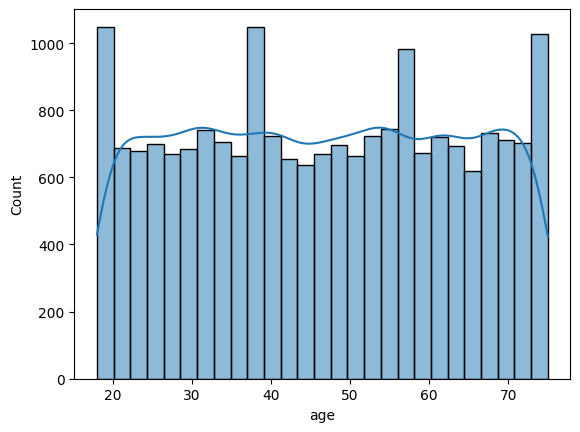

In [ ]:
sns.histplot(df1['age'],kde=True)



Most customers belong to the age group 15-40.

<Axes: xlabel='total_spend_usd', ylabel='Count'>

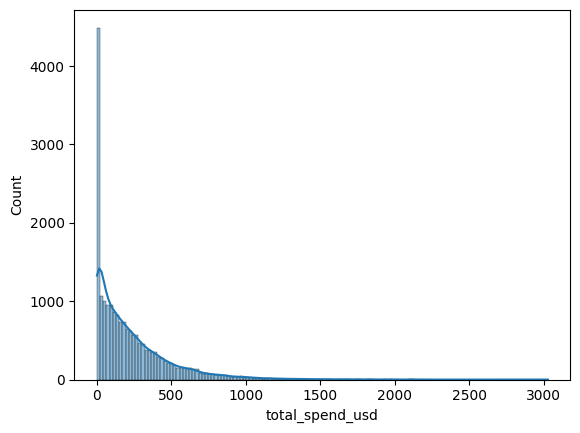

In [ ]:
sns.histplot(df1['total_spend_usd'],kde=True)



The distribution of total spending is highly right-skewed. Most customers spend relatively small amounts, while a few customers contribute significantly higher spending, indicating the presence of high-value customers.

<Axes: xlabel='Customer_tenure', ylabel='Count'>

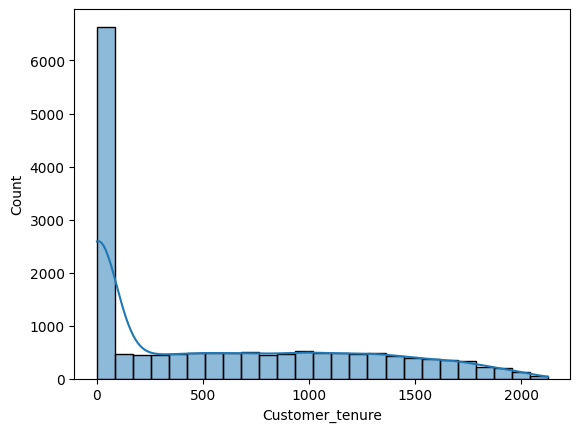

In [ ]:
sns.histplot(df1['Customer_tenure'],kde=True)



Customer tenure is positively skewed. A large number of customers have very short tenures, indicating one-time purchases, while fewer customers remain active for longer durations.

<Axes: xlabel='recency', ylabel='Count'>

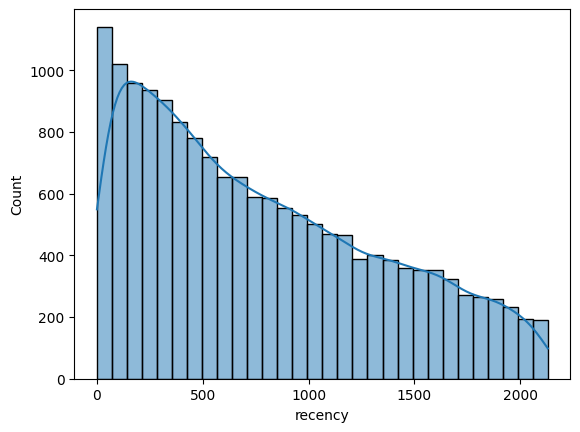

In [ ]:
sns.histplot(df1['recency'],kde=True)

The recency distribution is right-skewed, indicating that most customers have purchased recently, whereas a smaller number of customers have not made purchases for a long period and may be at risk of churn.

<Axes: xlabel='country', ylabel='count'>

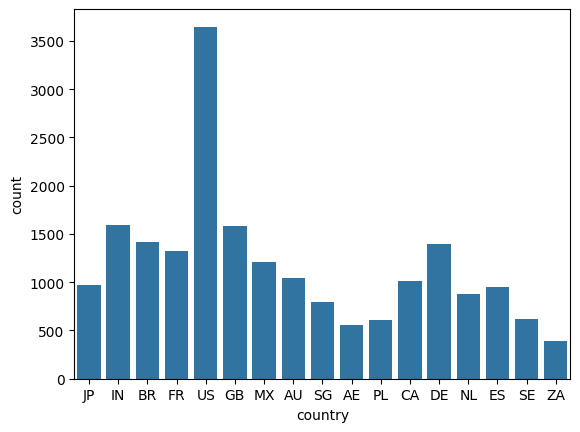

In [ ]:
sns.countplot(x='country',data=df1)



The company has a strong customer base in the US market. Marketing campaigns and customer retention strategies can be prioritized in these high-customer regions to maximize revenue and business growth.

<Axes: xlabel='preferred_payment', ylabel='count'>

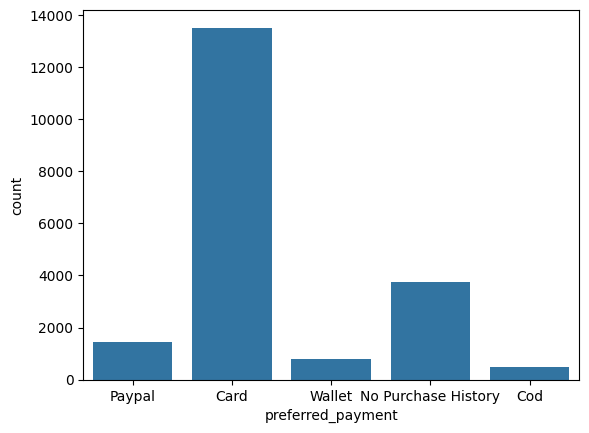

In [ ]:
sns.countplot(x='preferred_payment',data=df1)



Since Card is the dominant payment method, ensuring a seamless and secure card payment experience is essential. Customers with no purchase history can be targeted with personalized offers to encourage their first purchase

<Axes: xlabel='preferred_device_ord', ylabel='count'>

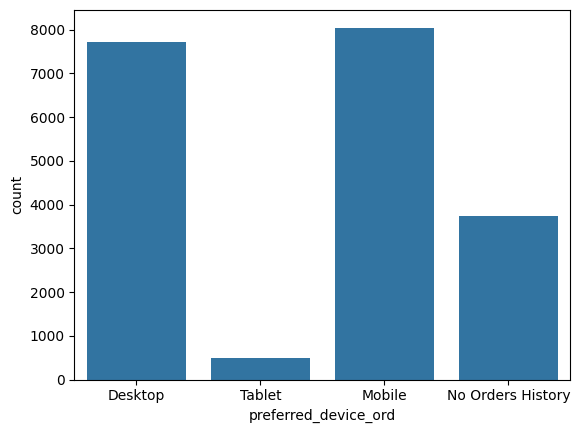

In [ ]:
sns.countplot(x='preferred_device_ord',data=df1)



The company should prioritize optimizing the shopping experience for Mobile and Desktop users, as these devices contribute the majority of customer interactions and purchases.

<Axes: xlabel='spending_category', ylabel='count'>

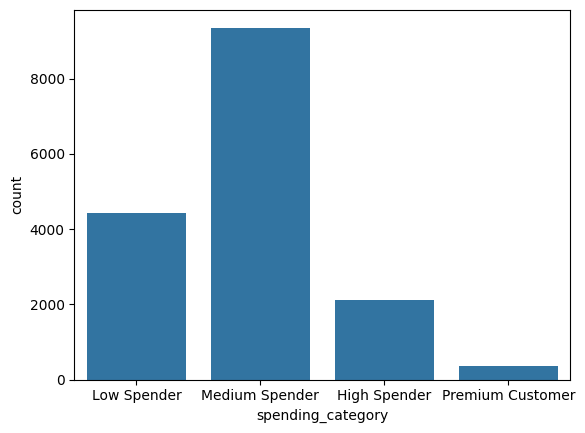

In [ ]:
sns.countplot(x='spending_category',data=df1)

Medium Spenders represent the largest customer segment and provide an opportunity for upselling strategies. Premium Customers, although fewer in number, are highly valuable and should be retained through loyalty programs and personalized marketing campaigns.

In [ ]:
df1.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,Customer_tenure,tenure_category,recency,Frequency,Monetary,spending_category
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,2025-06-25 14:09:53,0,low,1,1195.0,VIP Customer,128.0,2,115.39,Medium Spender
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,2025-01-02 01:01:29,0,low,1,382.0,VIP Customer,302.0,2,68.52,Low Spender
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,2025-08-28 11:01:14,0,low,0,0.0,New Customer,1945.0,1,66.72,Low Spender
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,2024-11-27 23:38:49,0,medium,1,1035.0,VIP Customer,822.0,2,279.86,Medium Spender
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,2025-01-29 23:45:28,0,medium,1,228.0,Loyal Customer,274.0,3,271.29,Medium Spender


Bivariate Analysis

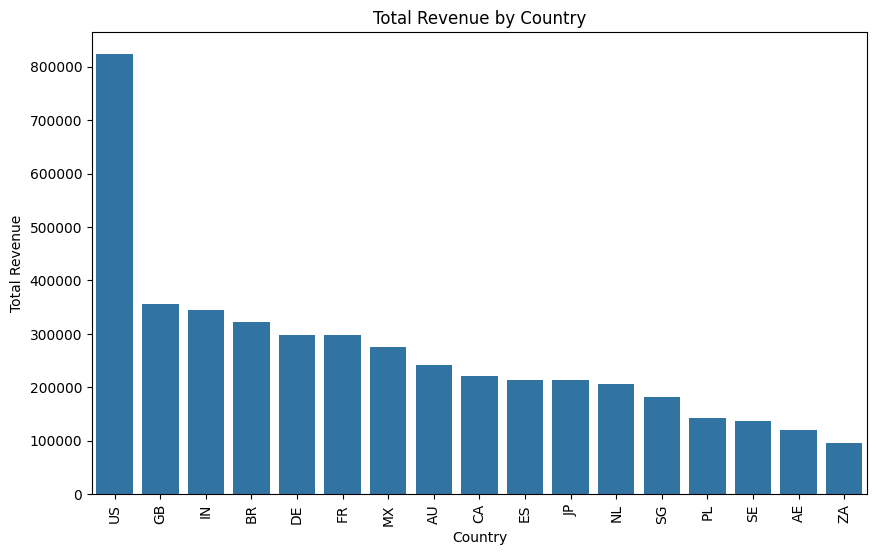

In [ ]:
country_rev=df1.groupby('country')['total_spend_usd'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=country_rev.index,y=country_rev.values)
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.show()

United States is getting the highest revenue than most of the countries.

Age_group vs Spending

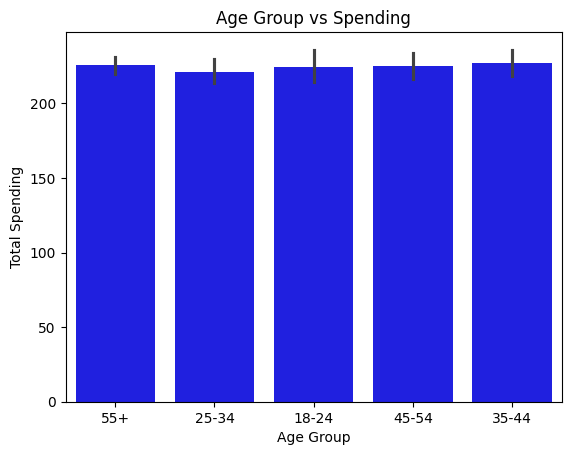

In [ ]:
sns.barplot(x='age_group',y='total_spend_usd',data=df1,color='b')
plt.title('Age Group vs Spending')
plt.xlabel('Age Group')
plt.ylabel('Total Spending')
plt.show()

According to the visual agegroup of 35-44 are spending more than other age groups.But the difference is very minimal between all of them.

Marketing vs total_spend_usd

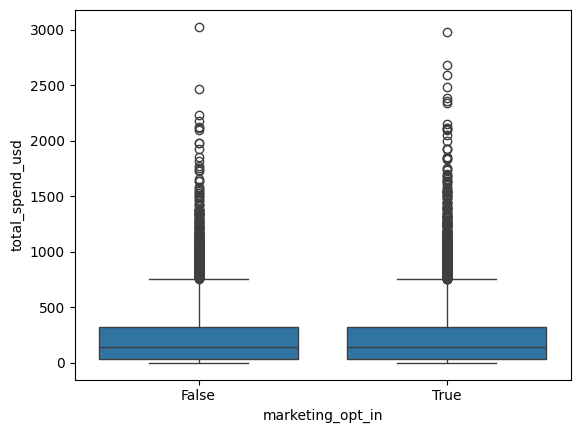

In [ ]:
sns.boxplot(
    x='marketing_opt_in',
    y='total_spend_usd',
    data=df1
)
plt.show()

The spending customers of both opted_in and opted_out are more similar to eachother tih only slight difference.The median spending of customer and inter quartile range show a slight differnce in there method but with marketing who optedin for spending the cusotmers doesnot have high customer impact.

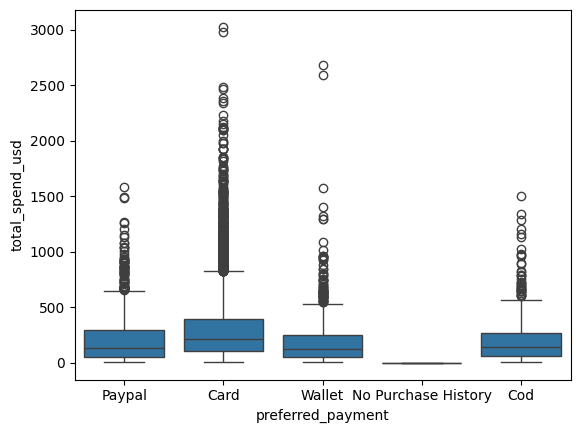

In [ ]:
sns.boxplot(
    x='preferred_payment',
    y='total_spend_usd',
    data=df1
)
plt.show()

We can conclude that most of the payment is done using card where it ranges between 100  to 400  of median range.The median spending is around 150-250.There are some very high spenders (outliers) reaching up to 3000 .The purchase history has gone to level 0$ where exactly someof them has not done any purchase.  

Preferred_device_ord vs Total_spend_usd

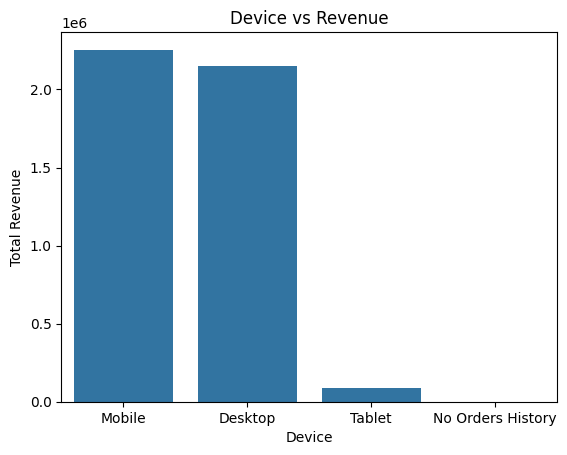

In [ ]:
device_rev=df1.groupby('preferred_device_ord')['total_spend_usd'].sum().sort_values(ascending=False)
sns.barplot(
    x=device_rev.index,
    y=device_rev.values,

)
plt.title('Device vs Revenue')
plt.xlabel('Device')
plt.ylabel('Total Revenue')
plt.show()

By this visual we can clearly say that mobile is producing the highest revenue as they have ordered most than compared to restof them.Tablet is providing least revenue in this category.

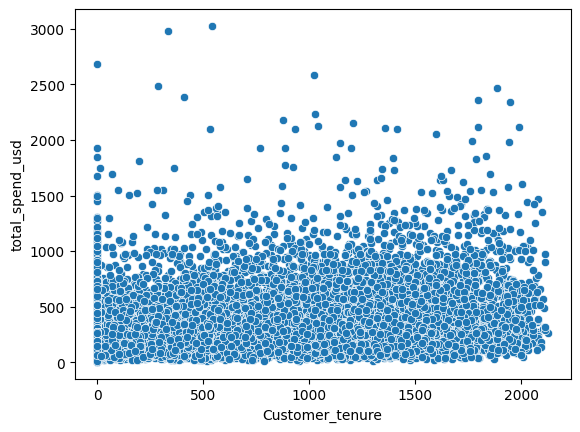

In [ ]:
sns.scatterplot(
    x='Customer_tenure',
    y='total_spend_usd',
    data=df1
)
plt.show()

The majority of customers spend less than $1000 across all tenure levels. While a small number of customers exhibit significantly higher spending, these high-value customers are spread across both low and high tenure groups. This suggests that customer tenure alone does not strongly influence spending behavior.

Recency vs Total_spend_usd

<Axes: xlabel='recency', ylabel='total_spend_usd'>

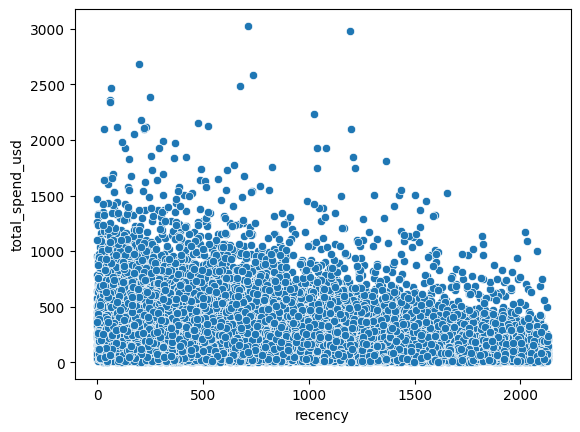

In [ ]:
sns.scatterplot(
    x='recency',
    y='total_spend_usd',
    data=df1
)

The scatter plot indicates a weak negative relationship between recency and total spending. Customers with lower recency values (recent purchasers) tend to exhibit higher spending, whereas customers with higher recency values generally show lower spending levels. This suggests that recently active customers contribute more revenue than inactive customers.

Spending Category vs Revenue

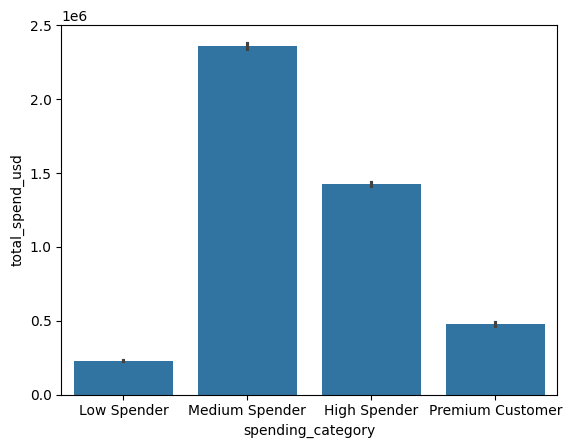

In [ ]:

sns.barplot(
    x='spending_category',
    y='total_spend_usd',
    data=df1,
    estimator=sum
)
plt.show()

Medium Spenders contribute the highest total revenue, followed by High Spenders. Although Premium Customers have the highest spending capacity per customer, their smaller population results in a lower overall revenue contribution. Low Spenders contribute the least revenue among all customer segments.

Performing the Corelation for the above data

In [ ]:
a=df1.drop(columns=['customer_id','Monetary','Frequency'],axis=1)

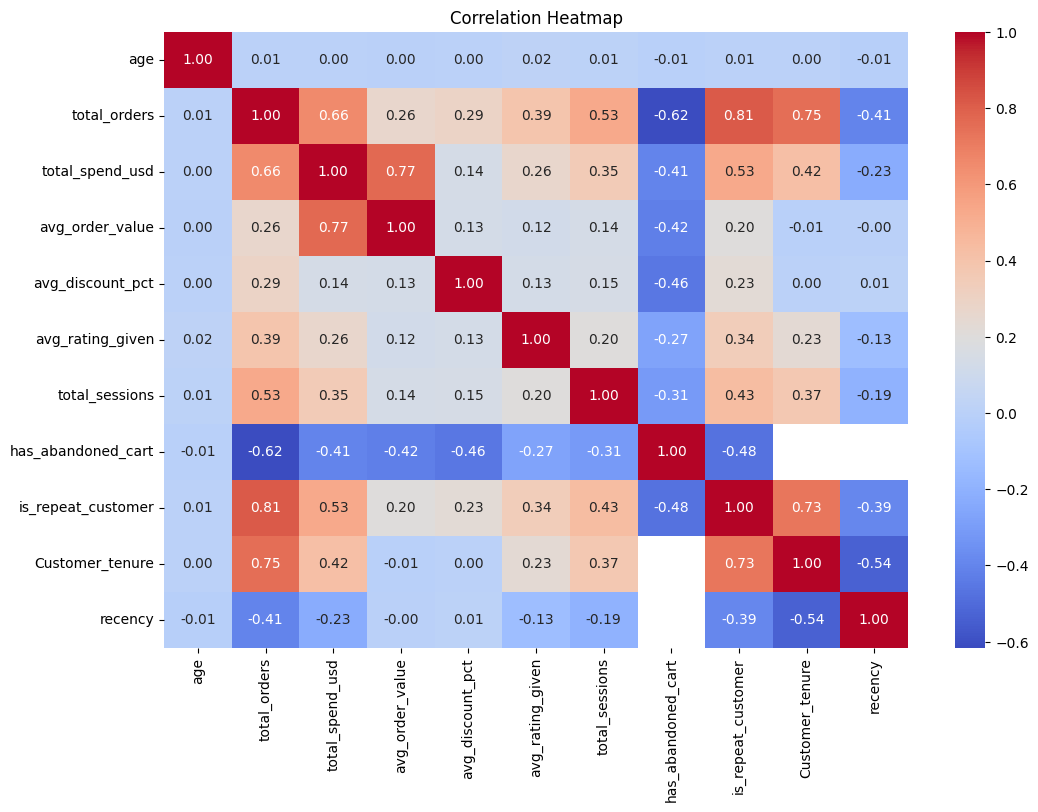

In [ ]:
num_cols = a.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

The correlation analysis reveals that most demographic variables, such as age, exhibit little to no relationship with purchasing behavior. Strong positive correlations are observed between total orders, total spending, customer tenure, and repeat customer status, indicating that engaged customers tend to generate higher revenue. Additionally, cart abandonment shows a negative relationship with orders and repeat purchases, suggesting that customers who abandon carts are generally less valuable to the business.

In [ ]:
df1.drop(columns=['Frequency', 'Monetary'], inplace=True)

In [ ]:
df1.to_csv('Ecommerce_cleanedAgain.csv',index=False)

In [ ]:
files.download('Ecommerce_cleanedAgain.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>